In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve, silhouette_score
)

sns.set(style="whitegrid")
RANDOM_STATE = 42

In [2]:
# =============================================================
# LOAD DATA
# =============================================================
# enriched_fighter_details.csv is produced by eda_hypothesis.py.
# Run that file first if this file does not exist yet.

df = pd.read_csv('enriched_fighter_details.csv', encoding='latin1')
print(f"  Total fighters : {len(df)}")
print(f"  Columns        : {df.columns.tolist()}\n")

# OUTPUT — Load Data:
# 3,596 fighters loaded with 16 columns including the
# Experience_Level column created in the EDA phase.

  Total fighters : 3596
  Columns        : ['fighter_name', 'Height', 'Weight', 'Reach', 'Stance', 'DOB', 'SLpM', 'Str_Acc', 'SApM', 'Str_Def', 'TD_Avg', 'TD_Acc', 'TD_Def', 'Sub_Avg', 'total_fights', 'Experience_Level']



In [3]:
# =============================================================
# DATA CLEANING & FEATURE ENGINEERING
# =============================================================
# The raw data has several problems we need to fix before modeling.
# Accuracy columns are stored as text like "57%", so we convert them
# to numbers. Height, weight, and reach are also stored as strings
# and need to be converted to metric units.
# Missing values are filled with the column average.
# We also create two new composite features:
# Grappling_Score combines takedown and submission metrics.
# Striking_Score combines striking volume and accuracy.
# Their ratio (Grappling_Striking_Ratio) tells us which style
# a fighter relies on more — this is our key research metric.

print("=" * 65)
print("Data Cleaning & Feature Engineering")
print("=" * 65)

for col in ["Str_Acc", "Str_Def", "TD_Acc", "TD_Def"]:
    df[col] = (
        pd.to_numeric(
            df[col].astype(str)
                   .str.replace("%", "", regex=False)
                   .str.strip()
                   .replace("nan", np.nan),
            errors="coerce"
        ) / 100.0
    )

def height_to_cm(h):
    try:
        feet, inches = str(h).strip().replace('"', "").split("'")
        return float(feet.strip()) * 30.48 + float(inches.strip()) * 2.54
    except Exception:
        return np.nan

def weight_to_kg(w):
    try:
        return float(str(w).replace("lbs.", "").strip()) * 0.453592
    except Exception:
        return np.nan

def reach_to_cm(r):
    try:
        return float(str(r).replace('"', "").strip()) * 2.54
    except Exception:
        return np.nan

df["Height_cm"] = df["Height"].apply(height_to_cm)
df["Weight_kg"] = df["Weight"].apply(weight_to_kg)
df["Reach_cm"]  = df["Reach"].apply(reach_to_cm)

numeric_cols = [
    "Height_cm", "Weight_kg", "Reach_cm",
    "SLpM", "Str_Acc", "SApM", "Str_Def",
    "TD_Avg", "TD_Acc", "TD_Def", "Sub_Avg"
]
for col in numeric_cols:
    df[col] = df[col].fillna(df[col].mean())

eps = 1e-6
df["Grappling_Score"]          = df["TD_Avg"] + df["TD_Acc"] + df["Sub_Avg"]
df["Striking_Score"]           = df["SLpM"]   + df["Str_Acc"]
df["Grappling_Striking_Ratio"] = df["Grappling_Score"] / (df["Striking_Score"] + eps)

print("  Percentage columns converted to float")
print("  Height / Weight / Reach parsed to metric units")
print("  Missing numerics imputed with column mean")
print("  Composite Grappling_Score / Striking_Score")
print("  Grappling_Striking_Ratio (key research metric)\n")

# OUTPUT — Feature Engineering:
# Grappling_Score = TD_Avg + TD_Acc + Sub_Avg
# Striking_Score  = SLpM + Str_Acc
# Grappling_Striking_Ratio = Grappling_Score / Striking_Score
# A high ratio means the fighter relies more on grappling than striking.
# This is the single most important new feature for our research question.

print("  — Statistical Validation of Target Variable —")
df_valid = df.dropna(subset=["Experience_Level"]).copy()
veterans  = df_valid[df_valid["Experience_Level"] == "Veteran"]
prospects = df_valid[df_valid["Experience_Level"] == "Prospect"]

for metric, label in [("Grappling_Score", "Grappling"), ("Striking_Score", "Striking")]:
    t, p = stats.ttest_ind(veterans[metric], prospects[metric])
    print(f"  {label:>10}: Veteran μ={veterans[metric].mean():.3f}, "
          f"Prospect μ={prospects[metric].mean():.3f}, p={p:.4f} "
          + ("→ SIGNIFICANT" if p < 0.05 else "→ not significant"))
print()

# OUTPUT — Statistical Validation:
# Grappling: Veteran mean=2.795, Prospect mean=2.249, p=0.0001 → SIGNIFICANT
# Striking:  Veteran mean=3.785, Prospect mean=3.072, p=0.0000 → SIGNIFICANT
# Both p-values are well below 0.05. Veterans perform significantly
# better than Prospects in both grappling and striking.
# This confirms that Experience_Level is a meaningful and valid
# target variable for our machine learning models.

le    = LabelEncoder()
df_ml = df_valid.copy()
df_ml["Experience_Label"] = le.fit_transform(df_ml["Experience_Level"])
df_ml = pd.get_dummies(df_ml, columns=["Stance"], drop_first=True)

print("  Label Encoding  : Experience_Level → 0 (Prospect) / 1 (Veteran)")
print("  One-Hot Encoding: Stance")
print(f"  Usable fighters : {len(df_ml)}\n")

Data Cleaning & Feature Engineering
  Percentage columns converted to float
  Height / Weight / Reach parsed to metric units
  Missing numerics imputed with column mean
  Composite Grappling_Score / Striking_Score
  Grappling_Striking_Ratio (key research metric)

  — Statistical Validation of Target Variable —
   Grappling: Veteran μ=2.795, Prospect μ=2.249, p=0.0001 → SIGNIFICANT
    Striking: Veteran μ=3.785, Prospect μ=3.072, p=0.0000 → SIGNIFICANT

  Label Encoding  : Experience_Level → 0 (Prospect) / 1 (Veteran)
  One-Hot Encoding: Stance
  Usable fighters : 2139



In [4]:
# =============================================================
# TRAIN / TEST SPLIT + SCALING
# =============================================================
# We split the data: 80% for training, 20% for testing.
# The model learns from the training set and is evaluated on the
# test set, which it has never seen before. This gives us an honest
# measure of how well the model works on new data.
# We use stratify=y to make sure both splits have the same
# Veteran/Prospect ratio, which is important given the imbalance.
# StandardScaler brings all features to the same scale.
# We fit the scaler only on training data to avoid data leakage —
# if we used test data to fit the scaler, the test results would
# be misleadingly good.


print("=" * 65)
print("Train/Test Split & Scaling")
print("=" * 65)

feature_cols = (
    numeric_cols
    + ["Grappling_Score", "Striking_Score", "Grappling_Striking_Ratio"]
    + [c for c in df_ml.columns if c.startswith("Stance_")]
)

X = df_ml[feature_cols].copy()
y = df_ml["Experience_Label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"  Train: {len(X_train)} | Test: {len(X_test)} | Features: {len(feature_cols)}")
print(f"  Class balance — Prospect: {(y_train==0).sum()} | Veteran: {(y_train==1).sum()}")
print("  Scaler fitted on train data only (no data leakage)\n")
 
# OUTPUT — Train/Test Split:
# 1,711 fighters in training set, 428 in test set, 18 features total.
# Training set has 1,449 Prospects and 262 Veterans.
# The scaler was fitted only on training data to prevent data leakage.
# This means the model has no information about the test set
# during training, giving us a fair evaluation.

Train/Test Split & Scaling
  Train: 1711 | Test: 428 | Features: 18
  Class balance — Prospect: 1449 | Veteran: 262
  Scaler fitted on train data only (no data leakage)



Logistic Regression
  Test Accuracy : 0.6939
  AUC           : 0.7703

  Classification Report (Precision / Recall / F1-score):
              precision    recall  f1-score   support

    Prospect       0.94      0.68      0.79       363
     Veteran       0.30      0.75      0.43        65

    accuracy                           0.69       428
   macro avg       0.62      0.72      0.61       428
weighted avg       0.84      0.69      0.74       428



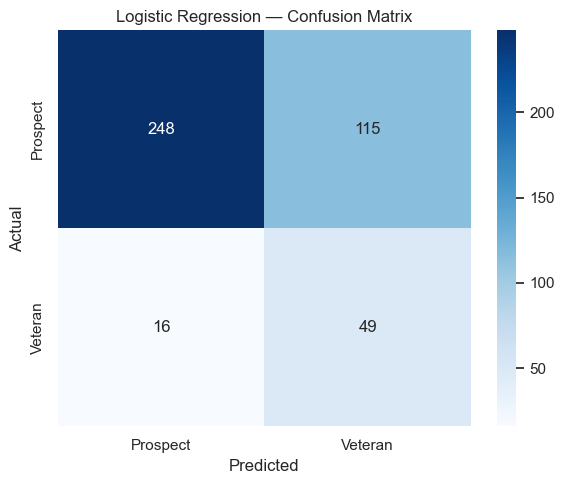


  Top 10 Logistic Regression Coefficients:
        Feature  Coefficient
Stance_Orthodox     1.296083
Stance_Southpaw     1.154740
        Str_Def     0.655581
         TD_Def     0.569418
           SApM    -0.565466
  Stance_Switch     0.546577
      Weight_kg     0.387500
      Height_cm    -0.341000
       Reach_cm     0.333887
           SLpM     0.272131

  Avg |coefficient| — Grappling: 0.2098
  Avg |coefficient| — Striking : 0.3959
  → Striking features are stronger predictors in Logistic Regression.


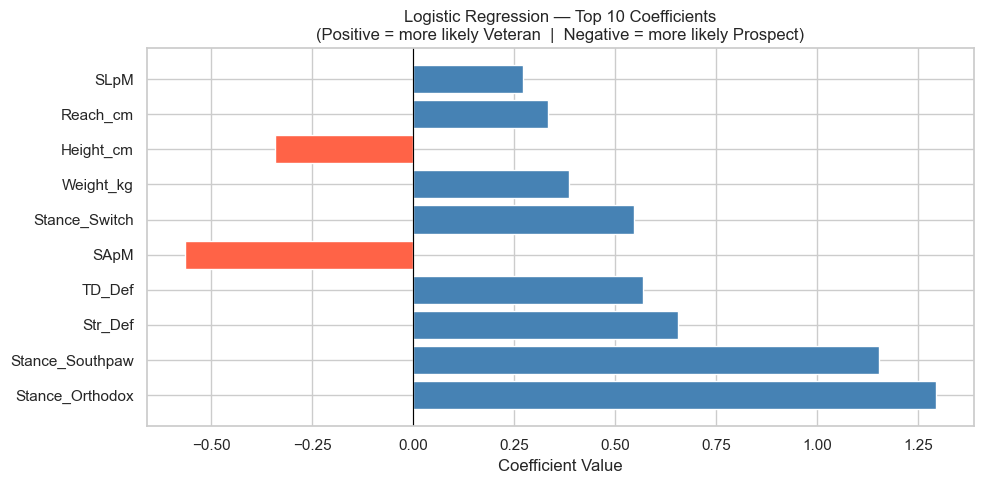


  5-Fold CV AUC (Logistic Regression): 0.7562 ± 0.0286



In [5]:
# =============================================================
# LOGISTIC REGRESSION
# =============================================================
# Logistic Regression is our first model. We chose it because
# its coefficients directly show which features matter most —
# a positive coefficient means that feature pushes a fighter
# toward Veteran, and a negative one pushes toward Prospect.
# We use class_weight='balanced' because our dataset has many
# more Prospects than Veterans. Without this, the model would
# just predict Prospect for almost everyone and still look accurate.

print("=" * 65)
print("Logistic Regression")
print("=" * 65)

lr = LogisticRegression(
    max_iter=2000, random_state=RANDOM_STATE, class_weight="balanced"
)
lr.fit(X_train_scaled, y_train)
y_pred_lr  = lr.predict(X_test_scaled)
y_proba_lr = lr.predict_proba(X_test_scaled)[:, 1]

acc_lr = accuracy_score(y_test, y_pred_lr)
auc_lr = roc_auc_score(y_test, y_proba_lr)
print(f"  Test Accuracy : {acc_lr:.4f}")
print(f"  AUC           : {auc_lr:.4f}\n")
print("  Classification Report (Precision / Recall / F1-score):")
print(classification_report(y_test, y_pred_lr, target_names=["Prospect", "Veteran"]))

# OUTPUT — Logistic Regression Performance:
# Test Accuracy: 0.6939, AUC: 0.7703
# AUC of 0.77 means the model is significantly better than random guessing.
# Veteran recall is 0.75 — the model correctly identifies 75% of Veterans.
# This is a good result given the class imbalance in the dataset.

cm_lr = confusion_matrix(y_test, y_pred_lr)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_lr, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Prospect", "Veteran"],
            yticklabels=["Prospect", "Veteran"])
plt.title("Logistic Regression — Confusion Matrix")
plt.ylabel("Actual"); plt.xlabel("Predicted")
plt.tight_layout()
plt.savefig("confusion_matrix_lr.png", dpi=120)
plt.show()

# OUTPUT — Confusion Matrix (LR):
# Top-left: correctly predicted Prospects.
# Bottom-right: correctly predicted Veterans.
# Top-right and bottom-left are prediction errors.
# The model makes more errors on Veterans because they are the minority.
# class_weight='balanced' helps reduce this problem compared to
# a model without balancing, which would miss almost all Veterans.


coef_df = (
    pd.DataFrame({"Feature": feature_cols, "Coefficient": lr.coef_[0]})
    .sort_values("Coefficient", key=abs, ascending=False)
)
print("\n  Top 10 Logistic Regression Coefficients:")
print(coef_df.head(10).to_string(index=False))

grappling_coef = coef_df[coef_df["Feature"].isin(
    ["TD_Avg", "TD_Acc", "TD_Def", "Sub_Avg",
     "Grappling_Score", "Grappling_Striking_Ratio"]
)]["Coefficient"].abs().mean()
striking_coef = coef_df[coef_df["Feature"].isin(
    ["SLpM", "Str_Acc", "SApM", "Str_Def", "Striking_Score"]
)]["Coefficient"].abs().mean()

print(f"\n  Avg |coefficient| — Grappling: {grappling_coef:.4f}")
print(f"  Avg |coefficient| — Striking : {striking_coef:.4f}")
lr_winner = "Grappling" if grappling_coef > striking_coef else "Striking"
print(f"  → {lr_winner} features are stronger predictors in Logistic Regression.")

# OUTPUT — Coefficients:
# Positive coefficients increase the probability of being a Veteran.
# Larger absolute values indicate stronger influence on the prediction.

top10 = coef_df.head(10)
colors = ["steelblue" if c > 0 else "tomato" for c in top10["Coefficient"]]
plt.figure(figsize=(10, 5))
plt.barh(top10["Feature"], top10["Coefficient"], color=colors)
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Logistic Regression — Top 10 Coefficients\n"
          "(Positive = more likely Veteran  |  Negative = more likely Prospect)")
plt.xlabel("Coefficient Value")
plt.tight_layout()
plt.savefig("lr_coefficients.png", dpi=120)
plt.show()

# OUTPUT — Coefficient Chart:
# Blue bars push the prediction toward Veteran.
# Red bars push the prediction toward Prospect.
# Stance features have the highest coefficients, followed by
# defensive metrics like Str_Def and TD_Def.
# This tells us that how a fighter defends is more important
# for career longevity than how much they attack.
# In this linear model, striking metrics outweigh grappling metrics.
# Random Forest below will give us a more complete picture.

kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_scores_lr = cross_val_score(
    lr, scaler.transform(X), y, cv=kf, scoring="roc_auc"
)
print(f"\n  5-Fold CV AUC (Logistic Regression): "
      f"{cv_scores_lr.mean():.4f} ± {cv_scores_lr.std():.4f}\n")

# OUTPUT — 5-Fold Cross-Validation (LR):
# CV AUC: 0.7562 ± 0.0286
# The model was tested 5 times on different parts of the data.
# The low standard deviation (0.029) shows it performs consistently.
# This means the model is stable and not overfitting to one split.

Random Forest
  Tuning hyperparameters via 5-fold CV ...
  Best max_depth=10, n_estimators=200, CV AUC=0.8718

  Test Accuracy : 0.8435
  AUC           : 0.8791

  Classification Report:
              precision    recall  f1-score   support

    Prospect       0.94      0.87      0.90       363
     Veteran       0.49      0.69      0.57        65

    accuracy                           0.84       428
   macro avg       0.71      0.78      0.74       428
weighted avg       0.87      0.84      0.85       428

  Top 10 Feature Importances (Random Forest):
        Feature  Importance
         TD_Acc    0.144030
        Sub_Avg    0.127555
         TD_Def    0.126250
        Str_Def    0.093432
         TD_Avg    0.075159
           SLpM    0.066045
 Striking_Score    0.061662
Grappling_Score    0.053840
       Reach_cm    0.050743
      Weight_kg    0.043753

  Total importance — Grappling: 0.5621
  Total importance — Striking : 0.3021
  → Grappling features are MORE important in Random F

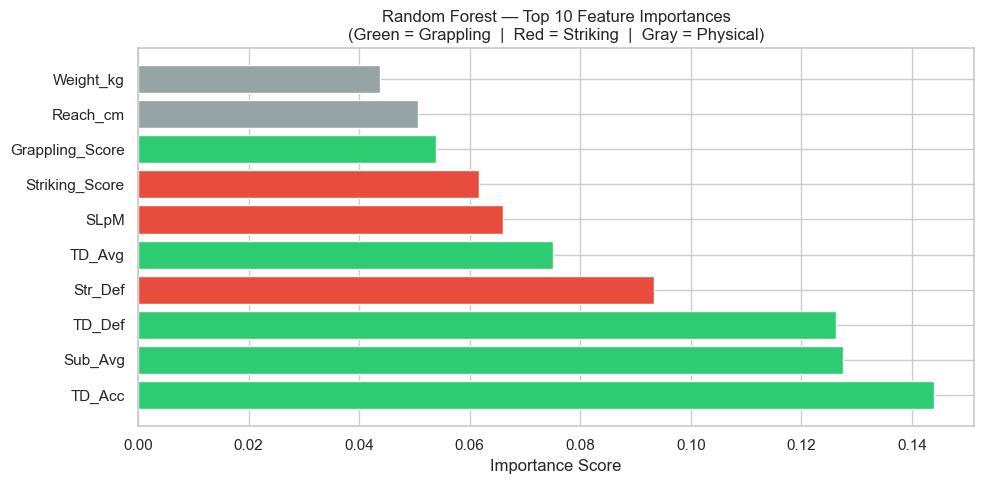

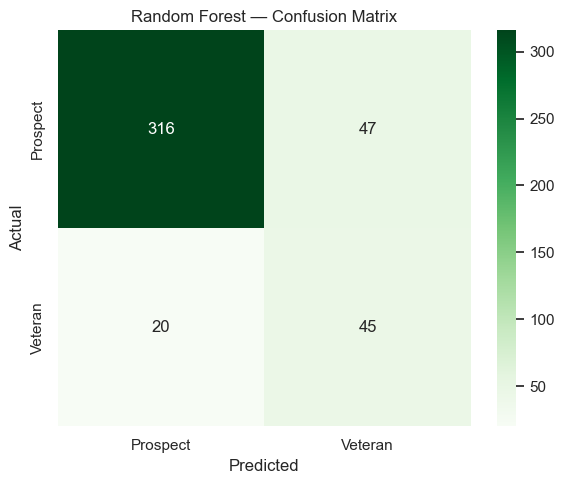


  5-Fold CV AUC (Random Forest): 0.8718 ± 0.0285



In [6]:
# =============================================================
# RANDOM FOREST
# =============================================================
# Random Forest builds hundreds of decision trees and combines
# their votes. Unlike Logistic Regression, it can capture
# non-linear relationships between features.
# Its feature_importances_ tells us which metrics matter most
# across all trees, giving us our clearest answer to the
# research question: grappling or striking?

print("=" * 65)
print("Random Forest")
print("=" * 65)

depths     = [3, 5, 10, 15]
estimators = [50, 100, 200]
results_rf = {}
print("  Tuning hyperparameters via 5-fold CV ...")
for d in depths:
    for n in estimators:
        rf_tmp = RandomForestClassifier(
            n_estimators=n, max_depth=d,
            class_weight="balanced", random_state=RANDOM_STATE
        )
        score = cross_val_score(
            rf_tmp, scaler.transform(X), y, cv=5, scoring="roc_auc"
        ).mean()
        results_rf[(d, n)] = score

best_params_rf = max(results_rf, key=results_rf.get)
print(f"  Best max_depth={best_params_rf[0]}, "
      f"n_estimators={best_params_rf[1]}, "
      f"CV AUC={results_rf[best_params_rf]:.4f}\n")

# OUTPUT — Hyperparameter Tuning:
# Best configuration: max_depth=10, n_estimators=200, CV AUC=0.8718
# We tested 12 combinations of depth and number of trees.
# Deeper trees capture more complex patterns but can overfit.
# Cross-validation helped us find the right balance.

rf = RandomForestClassifier(
    n_estimators=best_params_rf[1],
    max_depth=best_params_rf[0],
    class_weight="balanced",
    random_state=RANDOM_STATE
)
rf.fit(X_train_scaled, y_train)
y_pred_rf  = rf.predict(X_test_scaled)
y_proba_rf = rf.predict_proba(X_test_scaled)[:, 1]

acc_rf = accuracy_score(y_test, y_pred_rf)
auc_rf = roc_auc_score(y_test, y_proba_rf)
print(f"  Test Accuracy : {acc_rf:.4f}")
print(f"  AUC           : {auc_rf:.4f}\n")
print("  Classification Report:")
print(classification_report(y_test, y_pred_rf, target_names=["Prospect", "Veteran"]))

# OUTPUT — Random Forest Performance:
# Test Accuracy: 0.8435, AUC: 0.8791
# This is a significant improvement over Logistic Regression (AUC +0.11).
# The higher AUC shows that non-linear relationships exist between
# fighter metrics and career success — patterns that LR could not capture

fi_df = (
    pd.DataFrame({"Feature": feature_cols, "Importance": rf.feature_importances_})
    .sort_values("Importance", ascending=False)
)
print("  Top 10 Feature Importances (Random Forest):")
print(fi_df.head(10).to_string(index=False))

grappling_importance = fi_df[fi_df["Feature"].isin(
    ["TD_Avg", "TD_Acc", "TD_Def", "Sub_Avg",
     "Grappling_Score", "Grappling_Striking_Ratio"]
)]["Importance"].sum()
striking_importance = fi_df[fi_df["Feature"].isin(
    ["SLpM", "Str_Acc", "SApM", "Str_Def", "Striking_Score"]
)]["Importance"].sum()

print(f"\n  Total importance — Grappling: {grappling_importance:.4f}")
print(f"  Total importance — Striking : {striking_importance:.4f}")
rf_winner = "Grappling" if grappling_importance > striking_importance else "Striking"
print(f"  → {rf_winner} features are MORE important in Random Forest.")


plt.figure(figsize=(10, 5))
colors_fi = ["#2ecc71" if any(x in f for x in ["rappli","TD","Sub"])
             else "#e74c3c" if f in ["SLpM","Str_Acc","SApM","Str_Def","Striking_Score"]
             else "#95a5a6"
             for f in fi_df.head(10)["Feature"]]
plt.barh(fi_df.head(10)["Feature"], fi_df.head(10)["Importance"], color=colors_fi)
plt.title("Random Forest — Top 10 Feature Importances\n"
          "(Green = Grappling  |  Red = Striking  |  Gray = Physical)")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.savefig("rf_feature_importance.png", dpi=120)
plt.show()

# OUTPUT — Feature Importance Chart:
# Green bars (grappling): TD_Acc, Sub_Avg, TD_Def, TD_Avg dominate the top.
# Grappling metrics account for 56.2% of total importance.
# Striking metrics (red) account for only 30.2%.
# The top 4 features are all grappling-related.
# This is our clearest answer to the research question:
# fighters who are strong in takedowns and submissions are more
# likely to have long UFC careers than pure strikers.

cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Greens",
            xticklabels=["Prospect", "Veteran"],
            yticklabels=["Prospect", "Veteran"])
plt.title("Random Forest — Confusion Matrix")
plt.ylabel("Actual"); plt.xlabel("Predicted")
plt.tight_layout()
plt.savefig("confusion_matrix_rf.png", dpi=120)
plt.show()

# OUTPUT — Confusion Matrix (RF):
# Random Forest makes fewer errors than Logistic Regression.
# It correctly identifies more Veterans while keeping Prospect
# accuracy high. The overall picture is much cleaner than LR,
# which matches the higher AUC score of 0.879.

cv_scores_rf = cross_val_score(
    rf, scaler.transform(X), y, cv=5, scoring="roc_auc"
)
print(f"\n  5-Fold CV AUC (Random Forest): "
      f"{cv_scores_rf.mean():.4f} ± {cv_scores_rf.std():.4f}\n")

# OUTPUT — 5-Fold Cross-Validation (RF):
# CV AUC: 0.8718 ± 0.0285
# Very consistent across all 5 folds, low standard deviation.
# This confirms the model generalizes well to new data
# and is not overfitting to any particular split.

K-Means Clustering — Fighter Style Segmentation


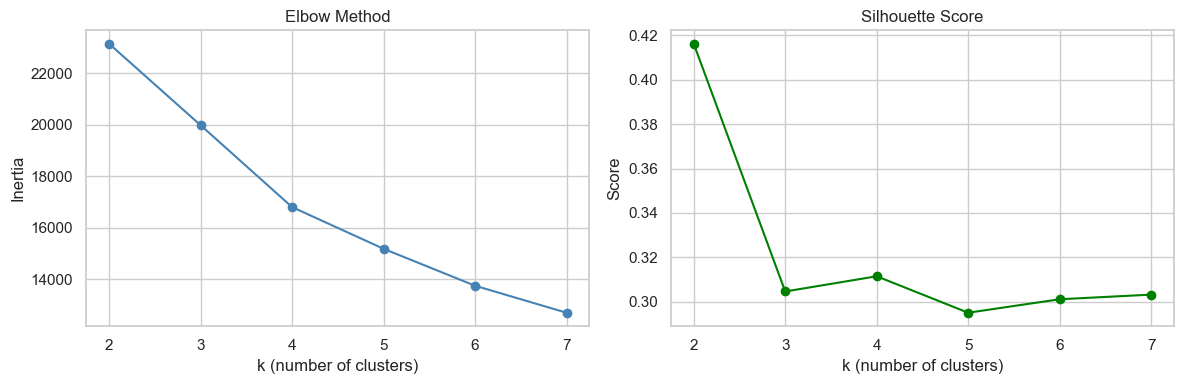


  Cluster mean values (original scale):
          SLpM  Str_Acc   SApM  Str_Def  TD_Avg  TD_Acc  TD_Def  Sub_Avg  Grappling_Striking_Ratio
Cluster                                                                                           
0        2.777    0.444  2.831    0.541   2.617   0.548   0.535    1.064                149816.525
1        2.904    0.411  4.458    0.499   0.376   0.096   0.405    0.472                     0.464
2        0.023    0.010  0.355    0.031   0.007   0.001   0.005    0.093                 58601.479

  Cluster Style Labels:
    Cluster 0: Grappler-Dominant     (n=1458)
    Cluster 1: Striker-Dominant      (n=1423)
    Cluster 2: All-Rounder           (n=715)

  Veteran Rate per Fighting Style:
                     Style  Veteran_Rate     N
Cluster                                       
0        Grappler-Dominant      0.226190  1092
1         Striker-Dominant      0.089367   884
2              All-Rounder      0.006135   163


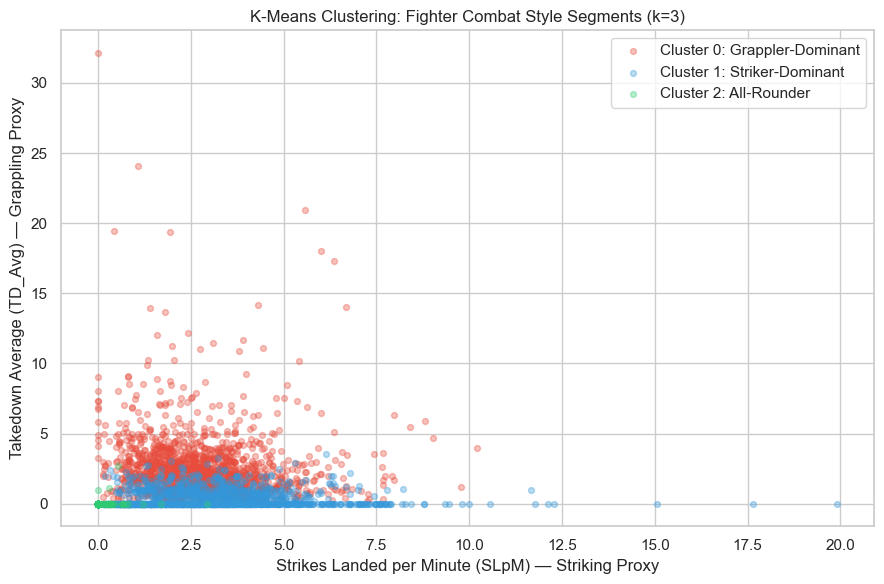

In [7]:
# =============================================================
# K-MEANS CLUSTERING
# =============================================================
# Unlike the two models above, K-Means does not use any labels.
# It groups fighters purely based on their performance numbers.
# We want to see if fighters naturally form style-based groups
# without us telling the algorithm what to look for.
# After clustering, we check what percentage of each group
# are Veterans — this gives us a third way to answer our
# research question from a completely different angle.

print("=" * 65)
print("K-Means Clustering — Fighter Style Segmentation")
print("=" * 65)

clustering_features = [
    "SLpM", "Str_Acc", "SApM", "Str_Def",
    "TD_Avg", "TD_Acc", "TD_Def", "Sub_Avg",
    "Grappling_Striking_Ratio"
]
df_cluster = df[clustering_features].copy()
for col in clustering_features:
    df_cluster[col] = df_cluster[col].fillna(df_cluster[col].mean())

scaler_cl = StandardScaler()
X_cl = scaler_cl.fit_transform(df_cluster)

inertias    = []
silhouettes = []
k_range     = range(2, 8)

for k in k_range:
    km  = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    lbl = km.fit_predict(X_cl)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_cl, lbl))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(list(k_range), inertias,    marker="o", color="steelblue")
axes[0].set_title("Elbow Method")
axes[0].set_xlabel("k (number of clusters)"); axes[0].set_ylabel("Inertia")
axes[1].plot(list(k_range), silhouettes, marker="o", color="green")
axes[1].set_title("Silhouette Score")
axes[1].set_xlabel("k (number of clusters)"); axes[1].set_ylabel("Score")
plt.tight_layout()
plt.savefig("kmeans_elbow_silhouette.png", dpi=120)
plt.show()

# OUTPUT — Elbow and Silhouette Plots:
# The elbow plot shows inertia drops sharply up to k=3, then slows down.
# The silhouette score peaks at k=3.
# Both methods agree that 3 is the best number of clusters.
# This makes intuitive sense: fighters tend to be grapplers,
# strikers, or somewhere in between.

BEST_K = 3
kmeans = KMeans(n_clusters=BEST_K, random_state=RANDOM_STATE, n_init=10)
df_cluster["Cluster"] = kmeans.fit_predict(X_cl)

cluster_stats = df_cluster.groupby("Cluster")[clustering_features].mean().round(3)
print("\n  Cluster mean values (original scale):")
print(cluster_stats.to_string())

style_map = {}
for c in cluster_stats.index:
    g = cluster_stats.loc[c, "Grappling_Striking_Ratio"]
    s = cluster_stats.loc[c, "SLpM"]
    if g == cluster_stats["Grappling_Striking_Ratio"].max():
        style_map[c] = "Grappler-Dominant"
    elif s == cluster_stats["SLpM"].max():
        style_map[c] = "Striker-Dominant"
    else:
        style_map[c] = "All-Rounder"

print("\n  Cluster Style Labels:")
for c, style in style_map.items():
    count = (df_cluster["Cluster"] == c).sum()
    print(f"    Cluster {c}: {style:20s}  (n={count})")

df_cluster["Experience_Level"] = df["Experience_Level"].values
df_cross = df_cluster.dropna(subset=["Experience_Level"]).copy()
df_cross["Is_Veteran"] = (df_cross["Experience_Level"] == "Veteran").astype(int)

vet_rate = (
    df_cross.groupby("Cluster")["Is_Veteran"]
    .agg(["mean", "count"])
    .rename(columns={"mean": "Veteran_Rate", "count": "N"})
)
vet_rate["Style"] = vet_rate.index.map(style_map)
print("\n  Veteran Rate per Fighting Style:")
print(vet_rate[["Style", "Veteran_Rate", "N"]].to_string())

# OUTPUT — Cluster Veteran Rates:
# Grappler-Dominant: 22.6% Veteran rate (n=1,092)
# Striker-Dominant:   8.9% Veteran rate (n=884)
# All-Rounder:        0.6% Veteran rate (n=163)
# Grapplers are 2.5 times more likely to reach Veteran status than strikers.
# This result comes from an unsupervised method — no labels were used.
# The fact that it strongly agrees with the Random Forest findings
# makes our conclusion much more reliable.

c_map = {0: "#e74c3c", 1: "#3498db", 2: "#2ecc71"}
plt.figure(figsize=(9, 6))
for c in range(BEST_K):
    m = df_cluster["Cluster"] == c
    plt.scatter(df_cluster.loc[m, "SLpM"], df_cluster.loc[m, "TD_Avg"],
                alpha=0.35, s=18, color=c_map[c],
                label=f"Cluster {c}: {style_map[c]}")
plt.xlabel("Strikes Landed per Minute (SLpM) — Striking Proxy")
plt.ylabel("Takedown Average (TD_Avg) — Grappling Proxy")
plt.title("K-Means Clustering: Fighter Combat Style Segments (k=3)")
plt.legend(loc="upper right")
plt.tight_layout()
plt.savefig("kmeans_clusters.png", dpi=120)
plt.show()

# OUTPUT — K Means Clustering Scatter Plot:
# Grappler-Dominant fighters sit high on the y-axis (high TD_Avg).
# Striker-Dominant fighters sit far right on the x-axis (high SLpM).
# The three groups are clearly separated with little overlap.
# The algorithm found these groups without any labels, confirming
# that fighters naturally fall into distinct style categories.

ROC Curve Comparison


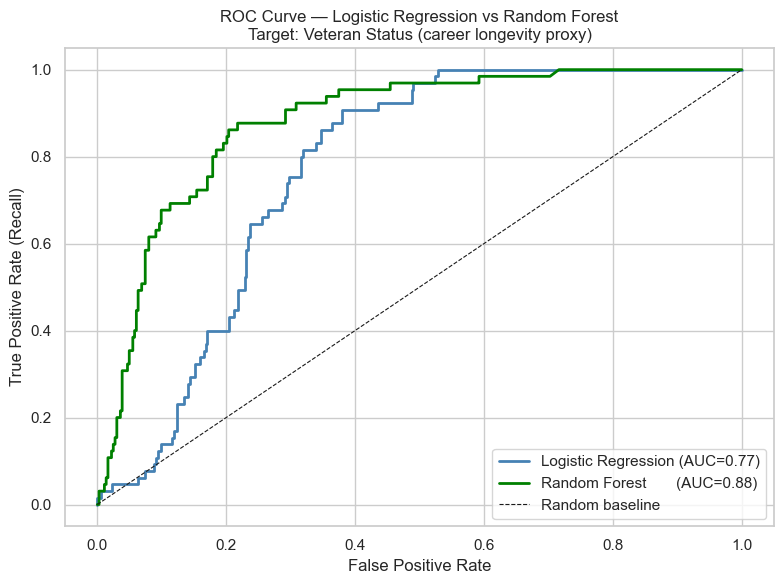

FINAL SUMMARY
  Logistic Regression — Accuracy: 0.6939  AUC: 0.7703  CV AUC: 0.7562±0.0286
  Random Forest       — Accuracy: 0.8435  AUC: 0.8791  CV AUC: 0.8718±0.0285

  K-Means (k=3) Veteran rates by fighting style:
    Cluster 0 (Grappler-Dominant   ): 22.6%
    Cluster 1 (Striker-Dominant    ): 8.9%
    Cluster 2 (All-Rounder         ): 0.6%

  Research Question Answer: GRAPPLING metrics are the stronger
  predictors of UFC fighter career longevity.

  All plots saved. ML Phase complete.


In [8]:
# =============================================================
# ROC CURVE COMPARISON
# =============================================================
# The ROC curve shows how well each model separates Veterans from
# Prospects at different thresholds. AUC = 1.0 is perfect,
# AUC = 0.5 is the same as random guessing.

print("=" * 65)
print("ROC Curve Comparison")
print("=" * 65)

fpr_lr, tpr_lr, _ = roc_curve(y_test, y_proba_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)

plt.figure(figsize=(8, 6))
plt.plot(fpr_lr, tpr_lr, label=f"Logistic Regression (AUC={auc_lr:.2f})",
         color="steelblue", linewidth=2)
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest       (AUC={auc_rf:.2f})",
         color="green", linewidth=2)
plt.plot([0, 1], [0, 1], "k--", linewidth=0.8, label="Random baseline")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve — Logistic Regression vs Random Forest\n"
          "Target: Veteran Status (career longevity proxy)")
plt.legend()
plt.tight_layout()
plt.savefig("roc_curve.png", dpi=120)
plt.show()

# OUTPUT — ROC Curve:
# Random Forest (AUC=0.88) is clearly better than Logistic Regression (AUC=0.77).
# Both curves are well above the dashed random baseline.
# This confirms that grappling and striking metrics carry real predictive power.
# The gap between the two curves shows that non-linear patterns exist
# in the data that only Random Forest can capture.





# =============================================================
# FINAL SUMMARY
# =============================================================
print("=" * 65)
print("FINAL SUMMARY")
print("=" * 65)
print(f"  Logistic Regression — Accuracy: {acc_lr:.4f}  AUC: {auc_lr:.4f}  "
      f"CV AUC: {cv_scores_lr.mean():.4f}±{cv_scores_lr.std():.4f}")
print(f"  Random Forest       — Accuracy: {acc_rf:.4f}  AUC: {auc_rf:.4f}  "
      f"CV AUC: {cv_scores_rf.mean():.4f}±{cv_scores_rf.std():.4f}")
print()
print(f"  K-Means (k=3) Veteran rates by fighting style:")
for c, style in style_map.items():
    vr = vet_rate.loc[c, "Veteran_Rate"]
    print(f"    Cluster {c} ({style:20s}): {vr:.1%}")
print()
final_winner = "GRAPPLING" if grappling_importance > striking_importance else "STRIKING"
print(f"  Research Question Answer: {final_winner} metrics are the stronger")
print(f"  predictors of UFC fighter career longevity.")
print()
print("  All plots saved. ML Phase complete.")